Using device: cuda
Classes: ['Vertical', 'defect free', 'hole', 'horizontal', 'lines', 'stain']

Training ANN...
Epoch [1/10], Train Loss: 3.6616, Val Loss: 0.7610
Epoch [2/10], Train Loss: 0.9048, Val Loss: 0.7937
Epoch [3/10], Train Loss: 0.9070, Val Loss: 0.4969
Epoch [4/10], Train Loss: 0.6310, Val Loss: 0.4082
Epoch [5/10], Train Loss: 0.5722, Val Loss: 0.4297
Epoch [6/10], Train Loss: 0.4958, Val Loss: 0.3226
Epoch [7/10], Train Loss: 0.4212, Val Loss: 0.3613
Epoch [8/10], Train Loss: 0.4325, Val Loss: 0.3098
Epoch [9/10], Train Loss: 0.4422, Val Loss: 0.3401
Epoch [10/10], Train Loss: 0.4044, Val Loss: 0.3578

Classification Report:
               precision    recall  f1-score   support

    Vertical       0.31      0.36      0.33        14
 defect free       0.96      0.95      0.95       248
        hole       0.51      0.57      0.54        44
  horizontal       0.00      0.00      0.00        18
       lines       0.68      0.74      0.71        23
       stain       0.83   

c:\ProgramData\anaconda3\envs\fabric_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\envs\fabric_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\envs\fabric_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

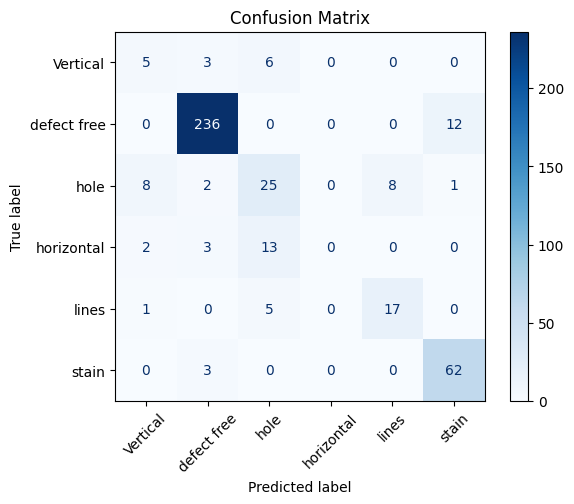


Training CNN...
Epoch [1/10], Train Loss: 0.6969, Val Loss: 0.3236
Epoch [2/10], Train Loss: 0.4139, Val Loss: 0.2814
Epoch [3/10], Train Loss: 0.3585, Val Loss: 0.2723
Epoch [4/10], Train Loss: 0.3045, Val Loss: 0.1846
Epoch [5/10], Train Loss: 0.2456, Val Loss: 0.1718
Epoch [6/10], Train Loss: 0.2159, Val Loss: 0.1652
Epoch [7/10], Train Loss: 0.2063, Val Loss: 0.1463
Epoch [8/10], Train Loss: 0.1686, Val Loss: 0.1382
Epoch [9/10], Train Loss: 0.1612, Val Loss: 0.1354
Epoch [10/10], Train Loss: 0.1472, Val Loss: 0.1422

Classification Report:
               precision    recall  f1-score   support

    Vertical       0.90      0.64      0.75        14
 defect free       1.00      0.95      0.98       248
        hole       0.84      0.73      0.78        44
  horizontal       0.65      0.83      0.73        18
       lines       0.79      0.96      0.86        23
       stain       0.84      1.00      0.92        65

    accuracy                           0.92       412
   macro avg 

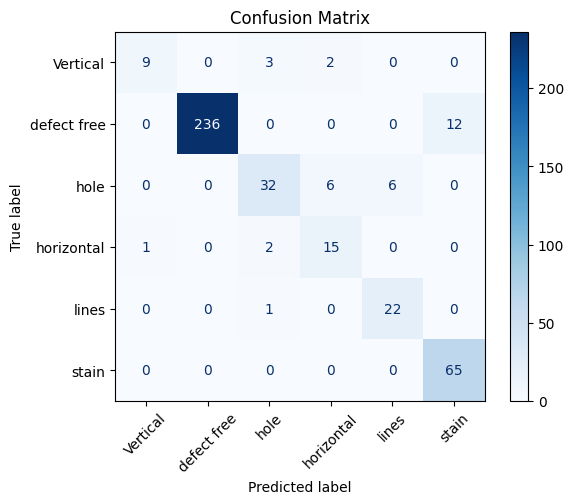

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ===============================
# 1. Device & Parameters
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
num_epochs = 10
learning_rate = 0.001
dataset_dir = "Fabric Defect Dataset"

# ===============================
# 2. Data Preprocessing
# ===============================
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # smaller than EfficientNet
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = datasets.ImageFolder(dataset_dir, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_classes = len(dataset.classes)
print("Classes:", dataset.classes)

# ===============================
# 3. ANN Model
# ===============================
class ANN(nn.Module):
    def __init__(self, num_classes):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(128*128*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ===============================
# 4. CNN Model
# ===============================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 32 * 32, 128)  # after pooling down
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # (3,128,128) -> (32,64,64)
        x = self.pool(self.relu(self.conv2(x)))  # (32,64,64) -> (64,32,32)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ===============================
# 5. Training Function
# ===============================
def train_model(model, train_loader, val_loader, num_epochs, learning_rate):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

# ===============================
# 6. Evaluation Function
# ===============================
def evaluate_model(model, test_loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

# ===============================
# 7. Run ANN
# ===============================
ann_model = ANN(num_classes).to(device)
print("\nTraining ANN...")
train_model(ann_model, train_loader, val_loader, num_epochs, learning_rate)
evaluate_model(ann_model, test_loader, dataset.classes)

# ===============================
# 8. Run CNN
# ===============================
cnn_model = SimpleCNN(num_classes).to(device)
print("\nTraining CNN...")
train_model(cnn_model, train_loader, val_loader, num_epochs, learning_rate)
evaluate_model(cnn_model, test_loader, dataset.classes)
